# **Global Vaccination Data Analysis**

##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Intern Name**     - Keval Vaishnav


# **Project Summary -**

This project analyzes five WHO Immunization Data Portal extracts (1980–2023) — vaccination **coverage**, disease **incidence rates**, **reported cases**, vaccine **introduction status**, and national **vaccination schedules** — to understand how vaccination effort relates to disease outcomes across countries and WHO regions, and to surface gaps that matter for public health policy and resource allocation.

The raw data required non-trivial cleaning before it was analysis-ready. Every one of the five files carried a stray metadata footer row that corrupted null counts and column dtypes. The coverage table mixed genuine country-level records with pre-aggregated regional, income-group, and global rollups under a single `GROUP` column, which would silently double-count numbers if not filtered out. Roughly 5,100 coverage records exceeded 100% (up to 32,000%), a clear administrative-reporting artifact that had to be flagged rather than trusted. Categorical fields like vaccine-introduction status (`INTRO`) and incidence denominators were recorded inconsistently (nine variants of "yes", two different string formats for the same per-capita denominator) and needed normalization before they could be grouped or counted correctly. Finally, the five tables used two different key-naming conventions for country identifiers, which had to be reconciled before any cross-table analysis was possible.

After cleaning, the notebook builds a country-year grain merged table (coverage joined with cases and incidence) that powers the core visual analysis: global trends in cases and coverage over time, regional disparities in coverage and vaccine introduction, the relationship between coverage and disease incidence, dose drop-off between first and later doses, and a geographic view of where coverage is weakest today.

A key limitation surfaced during this analysis: several EDA questions posed in the project brief — differences by gender, education level, urban/rural setting, population density, or seasonality — cannot be answered from these five files, since none of them contain demographic, geographic-density, or seasonal fields. This is called out explicitly in the conclusion rather than answered with fabricated relationships.

The findings point to concrete, data-grounded recommendations: prioritize resource allocation toward the specific countries with the lowest coverage for high-priority antigens (identified directly, by name, in this notebook); treat the drop-off between dose 1 and dose 3 as a program-design signal, not just a coverage number; and use the vaccine-introduction gap across WHO regions to guide global-health-policy conversations about which regions still lack access to newer vaccines (HPV, rotavirus, PCV) that other regions introduced years ago.

# **GitHub Link -**

https://github.com/KVAlwaysLearning/Vaccination_EDA

# **Streamlit App Link -**

https://vaccinationeda-app1.streamlit.app/

# **Problem Statement**

Analyze global vaccination data to understand trends in vaccination coverage, disease incidence, and effectiveness — clean the five source tables, reconcile them into an analysis-ready form, and use exploratory data analysis and visualization to surface patterns relevant to public health strategy, disease prevention, resource allocation, and global health policy.

#### **Define Your Business Objective?**

Identify where vaccination programs are working (rising coverage, falling incidence), where they are not (persistent low coverage, high incidence, large dose drop-off), and which vaccines/regions show introduction gaps — so that public health agencies, vaccine manufacturers, and policymakers can prioritize interventions, forecast demand, and target resources with evidence rather than guesswork.

# ***Let's Begin !***

### **Manually Upload the Data in csv/excel format using .zip file:**

**URL for data:** https://drive.google.com/drive/folders/1YQ6mNrZCrlEeBP4GH3VnLBNXb7OBD4tf

### **Unzipping the Uploaded .zip files**

In [ ]:
!unzip -q "/content/vaccine_data.zip" -d "/content/vaccine_data"

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)


### Dataset Loading

In [ ]:
# Load Dataset
# All five files are uploaded to /content/vaccine_data/ in Colab.
DATA_DIR = "/content/vaccine_data"

coverage_df = pd.read_excel(f"{DATA_DIR}/coverage-data.xlsx", sheet_name="Data")
incidence_df = pd.read_excel(f"{DATA_DIR}/incidence-rate-data.xlsx", sheet_name="Data")
cases_df = pd.read_excel(f"{DATA_DIR}/reported-cases-data.xlsx", sheet_name="Data")
intro_df = pd.read_excel(f"{DATA_DIR}/vaccine-introduction-data.xlsx", sheet_name="Data")
schedule_df = pd.read_excel(f"{DATA_DIR}/vaccine-schedule-data.xlsx", sheet_name="Data")

datasets = {
    "coverage_df": coverage_df,
    "incidence_df": incidence_df,
    "cases_df": cases_df,
    "intro_df": intro_df,
    "schedule_df": schedule_df,
}
print("Loaded:", list(datasets.keys()))


Loaded: ['coverage_df', 'incidence_df', 'cases_df', 'intro_df', 'schedule_df']


### Dataset First View

In [ ]:
# Dataset First Look
for name, df in datasets.items():
    print("="*100)
    print(name)
    display(df.head(3))


coverage_df


,GROUP,CODE,NAME,YEAR,ANTIGEN,ANTIGEN_DESCRIPTION,COVERAGE_CATEGORY,COVERAGE_CATEGORY_DESCRIPTION,TARGET_NUMBER,DOSES,COVERAGE
0,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,ADMIN,Administrative coverage,NaN,NaN,NaN
1,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,OFFICIAL,Official coverage,NaN,NaN,NaN
2,COUNTRIES,ABW,Aruba,2023.0,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b...",ADMIN,Administrative coverage,1044.0,945.0,90.52


incidence_df


,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,DENOMINATOR,INCIDENCE_RATE
0,COUNTRIES,ABW,Aruba,2023.0,CRS,Congenital rubella syndrome,"per 10,000 live births",0.0
1,COUNTRIES,ABW,Aruba,2023.0,DIPHTHERIA,Diphtheria,"per 1,000,000 total population",0.0
2,COUNTRIES,ABW,Aruba,2023.0,INVASIVE_MENING,Invasive meningococcal disease,"per 1,000,000 total population",9.3


cases_df


,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,CASES
0,COUNTRIES,ABW,Aruba,2023.0,CRS,Congenital rubella syndrome,0.0
1,COUNTRIES,ABW,Aruba,2023.0,DIPHTHERIA,Diphtheria,0.0
2,COUNTRIES,ABW,Aruba,2023.0,INVASIVE_MENING,Invasive meningococcal disease,1.0


intro_df


,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,DESCRIPTION,INTRO
0,AFG,Afghanistan,EMRO,2023.0,aP (acellular pertussis) vaccine,No
1,AFG,Afghanistan,EMRO,2023.0,Hepatitis A vaccine,No
2,AFG,Afghanistan,EMRO,2023.0,Hepatitis B vaccine,Yes


schedule_df


,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,VACCINECODE,VACCINE_DESCRIPTION,SCHEDULEROUNDS,TARGETPOP,TARGETPOP_DESCRIPTION,GEOAREA,AGEADMINISTERED,SOURCECOMMENT
0,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,1.0,NaN,General/routine,NATIONAL,M2,NaN
1,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,2.0,NaN,General/routine,NATIONAL,M4,NaN
2,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,3.0,NaN,General/routine,NATIONAL,M6,NaN


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
for name, df in datasets.items():
    print(f"{name:15s} -> rows: {df.shape[0]:>7,}   columns: {df.shape[1]}")


coverage_df     -> rows: 399,859   columns: 11
incidence_df    -> rows:  84,946   columns: 8
cases_df        -> rows:  84,870   columns: 7
intro_df        -> rows: 138,321   columns: 6
schedule_df     -> rows:   8,053   columns: 12


### Dataset Information

In [ ]:
# Dataset Info
for name, df in datasets.items():
    print("="*100)
    print(name)
    df.info()


coverage_df
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399859 entries, 0 to 399858
Data columns (total 11 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   GROUP                          399859 non-null  object 
 1   CODE                           399858 non-null  object 
 2   NAME                           398584 non-null  object 
 3   YEAR                           399858 non-null  float64
 4   ANTIGEN                        399858 non-null  object 
 5   ANTIGEN_DESCRIPTION            399858 non-null  object 
 6   COVERAGE_CATEGORY              399858 non-null  object 
 7   COVERAGE_CATEGORY_DESCRIPTION  399858 non-null  object 
 8   TARGET_NUMBER                  79030 non-null   float64
 9   DOSES                          79327 non-null   float64
 10  COVERAGE                       230477 non-null  float64
dtypes: float64(4), object(7)
memory usage: 33.6+ MB
incidence_df
<class 'pandas.cor

#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
for name, df in datasets.items():
    print(f"{name:15s} -> duplicate rows: {df.duplicated().sum()}")


coverage_df     -> duplicate rows: 0
incidence_df    -> duplicate rows: 0
cases_df        -> duplicate rows: 0
intro_df        -> duplicate rows: 0
schedule_df     -> duplicate rows: 0


#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
for name, df in datasets.items():
    print("="*100)
    print(name)
    print(df.isnull().sum())


coverage_df
GROUP                                 0
CODE                                  1
NAME                               1275
YEAR                                  1
ANTIGEN                               1
ANTIGEN_DESCRIPTION                   1
COVERAGE_CATEGORY                     1
COVERAGE_CATEGORY_DESCRIPTION         1
TARGET_NUMBER                    320829
DOSES                            320532
COVERAGE                         169382
dtype: int64
incidence_df
GROUP                      0
CODE                       1
NAME                       1
YEAR                       1
DISEASE                    1
DISEASE_DESCRIPTION        1
DENOMINATOR                1
INCIDENCE_RATE         23362
dtype: int64
cases_df
GROUP                      0
CODE                       1
NAME                       1
YEAR                       1
DISEASE                    1
DISEASE_DESCRIPTION        1
CASES                  19400
dtype: int64
intro_df
ISO_3_CODE     0
COUNTRYNAME    1
WHO_REGIO

In [ ]:
# The last row of every 'Data' sheet is a stray metadata footer, e.g. "Created: 2025-02-01 16:00 UTC",
# with every other column NaN. This is what is driving most of the "single missing value" columns above.
for name, df in datasets.items():
    print(name, "-> last row:")
    display(df.tail(1))


coverage_df -> last row:


,GROUP,CODE,NAME,YEAR,ANTIGEN,ANTIGEN_DESCRIPTION,COVERAGE_CATEGORY,COVERAGE_CATEGORY_DESCRIPTION,TARGET_NUMBER,DOSES,COVERAGE
399858,Created: 2025-02-01 16:00 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


incidence_df -> last row:


,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,DENOMINATOR,INCIDENCE_RATE
84945,Created: 2025-02-01 16:03 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN


cases_df -> last row:


,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,CASES
84869,Created: 2025-02-01 16:02 UTC,NaN,NaN,NaN,NaN,NaN,NaN


intro_df -> last row:


,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,DESCRIPTION,INTRO
138320,Created: 2025-02-01 07:09 UTC,NaN,NaN,NaN,NaN,NaN


schedule_df -> last row:


,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,VACCINECODE,VACCINE_DESCRIPTION,SCHEDULEROUNDS,TARGETPOP,TARGETPOP_DESCRIPTION,GEOAREA,AGEADMINISTERED,SOURCECOMMENT
8052,Created: 2025-02-01 16:10 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


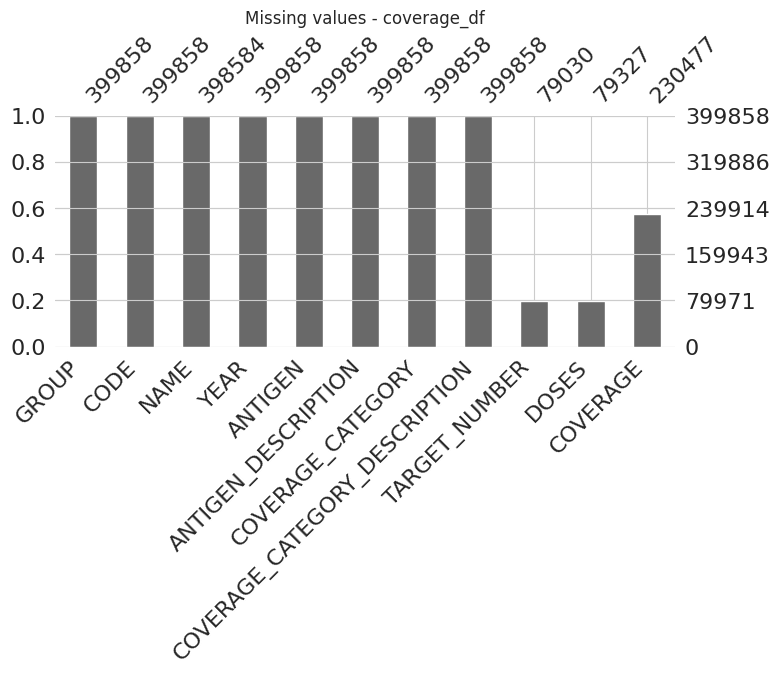

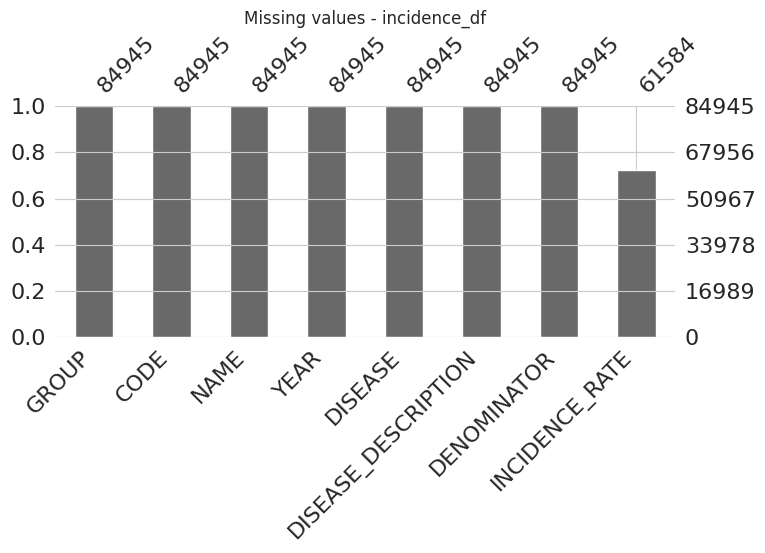

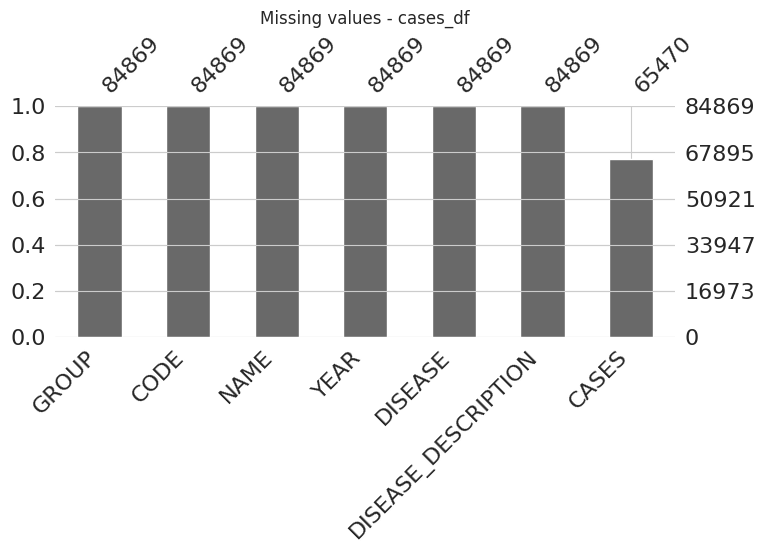

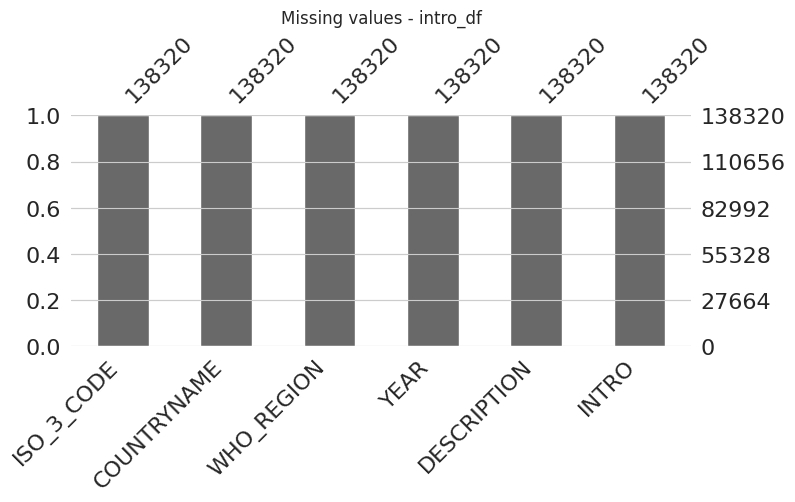

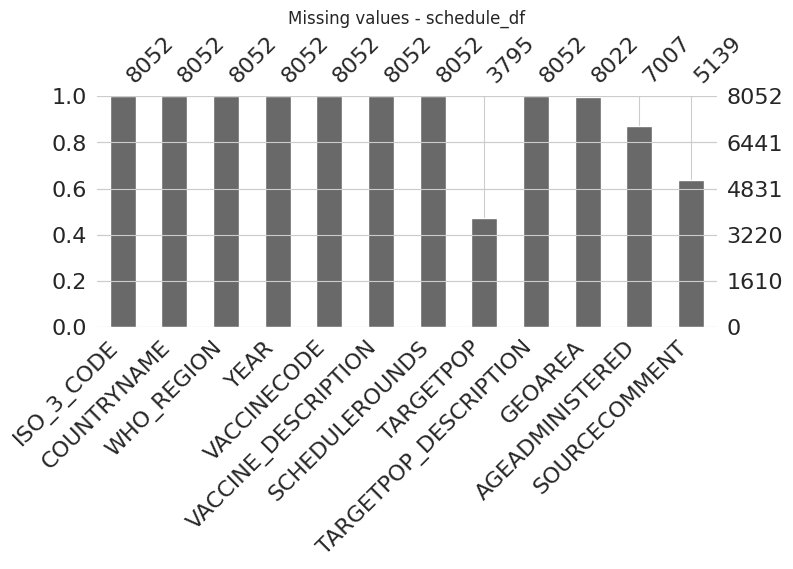

In [ ]:
# Visualizing the missing values (footer row dropped first so it doesn't dominate the plot)
for name, df in datasets.items():
    df_tmp = df.iloc[:-1]
    msno.bar(df_tmp, figsize=(8, 3))
    plt.title(f"Missing values - {name}")
    plt.show()


### What did you know about your dataset?

- Five WHO Immunization Data Portal extracts (1980–2023): vaccination **coverage** (399,859 rows), disease **incidence rate** (84,946 rows), **reported cases** (84,870 rows), vaccine **introduction status** (138,321 rows), and national **vaccination schedules** (8,053 rows).
- Every file has an identical structural defect: the **last row of the `Data` sheet is a metadata stamp** (e.g. "Created: 2025-02-01 16:00 UTC") with every real column left `NaN` — this must be dropped before any real null analysis or dtype casting.
- `coverage_df`'s `GROUP` column mixes genuine **country-level rows** with **pre-aggregated rollups** (`WHO_REGIONS`, `UNICEF_REGIONS`, `WB_LONG`, `WB_SHORT`, `DEVELOPMENT_STATUS`, `GAVI_PHASE5`, `GLOBAL`) — country-level analysis must filter to `GROUP == 'COUNTRIES'` or totals will be double-counted.
- Missingness in the numeric fields (`COVERAGE`, `DOSES`, `TARGET_NUMBER`, `CASES`, `INCIDENCE_RATE`) is **structural, not random** — not every antigen/disease/year/country combination is reported every year.
- `coverage_df`, `incidence_df`, `cases_df` key on `CODE`/`NAME`; `intro_df`, `schedule_df` key on `ISO_3_CODE`/`COUNTRYNAME` — these need to be reconciled to a common key before joining.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
for name, df in datasets.items():
    print(name, "->", list(df.columns))


coverage_df -> ['GROUP', 'CODE', 'NAME', 'YEAR', 'ANTIGEN', 'ANTIGEN_DESCRIPTION', 'COVERAGE_CATEGORY', 'COVERAGE_CATEGORY_DESCRIPTION', 'TARGET_NUMBER', 'DOSES', 'COVERAGE']
incidence_df -> ['GROUP', 'CODE', 'NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION', 'DENOMINATOR', 'INCIDENCE_RATE']
cases_df -> ['GROUP', 'CODE', 'NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION', 'CASES']
intro_df -> ['ISO_3_CODE', 'COUNTRYNAME', 'WHO_REGION', 'YEAR', 'DESCRIPTION', 'INTRO']
schedule_df -> ['ISO_3_CODE', 'COUNTRYNAME', 'WHO_REGION', 'YEAR', 'VACCINECODE', 'VACCINE_DESCRIPTION', 'SCHEDULEROUNDS', 'TARGETPOP', 'TARGETPOP_DESCRIPTION', 'GEOAREA', 'AGEADMINISTERED', 'SOURCECOMMENT']


In [ ]:
# Dataset Describe
for name, df in datasets.items():
    print("="*100)
    print(name)
    display(df.describe(include='all').T)


coverage_df


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
GROUP,399859,9,COUNTRIES,381041,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODE,399858,245,ETH,2031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME,398584,242,Ethiopia,2031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,399858.0,NaN,NaN,NaN,2009.207489,11.72053,1980.0,2002.0,2012.0,2019.0,2023.0
ANTIGEN,399858,69,DTPCV3,26015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ANTIGEN_DESCRIPTION,399858,69,"DTP-containing vaccine, 3rd dose",26015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COVERAGE_CATEGORY,399858,5,ADMIN,155576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COVERAGE_CATEGORY_DESCRIPTION,399858,5,Administrative coverage,155576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TARGET_NUMBER,79030.0,NaN,NaN,NaN,278019173.759516,54152442883.354065,0.0,32814.0,317871.5,2493048.0,11700000000000.0
DOSES,79327.0,NaN,NaN,NaN,3467241.121352,11256763.030974,-222288203.0,14469.0,152212.0,971018.5,126605212.0


incidence_df


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
GROUP,84946,4,COUNTRIES,82054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODE,84945,221,GLOBAL,424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME,84945,221,Global,424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,84945.0,NaN,NaN,NaN,2004.095791,12.595166,1980.0,1994.0,2005.0,2015.0,2023.0
DISEASE,84945,13,MEASLES,9196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DISEASE_DESCRIPTION,84945,13,Measles,9196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DENOMINATOR,84945,5,"per 1,000,000 total population",61480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
INCIDENCE_RATE,61584.0,NaN,NaN,NaN,109.448781,992.276983,0.0,0.0,0.0,4.6,69101.3


cases_df


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
GROUP,84870,4,COUNTRIES,82054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODE,84869,221,GLOBAL,424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME,84869,221,Global,424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,84869.0,NaN,NaN,NaN,2004.108261,12.591396,1980.0,1994.0,2005.0,2015.0,2023.0
DISEASE,84869,13,MEASLES,9196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DISEASE_DESCRIPTION,84869,13,Measles,9196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CASES,65470.0,NaN,NaN,NaN,4472.408569,61144.550256,0.0,0.0,1.0,63.0,4583555.0


intro_df


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ISO_3_CODE,138321,195,AFG,747,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COUNTRYNAME,138320,194,Afghanistan,747,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WHO_REGION,138320,6,EURO,34523,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,138320.0,NaN,NaN,NaN,2001.267879,17.679511,1940.0,1992.0,2006.0,2015.0,2023.0
DESCRIPTION,138320,21,Seasonal Influenza vaccine,14715,NaN,NaN,NaN,NaN,NaN,NaN,NaN
INTRO,138320,9,No,97695,NaN,NaN,NaN,NaN,NaN,NaN,NaN


schedule_df


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ISO_3_CODE,8053,214,RUS,126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COUNTRYNAME,8052,213,Russian Federation,126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WHO_REGION,8052,6,EURO,2156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,8052.0,NaN,NaN,NaN,2022.941505,0.441237,2019.0,2023.0,2023.0,2023.0,2023.0
VACCINECODE,8052,86,TD_S,967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VACCINE_DESCRIPTION,8052,86,Td (Tetanus toxoid and diphtheria for older ch...,967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCHEDULEROUNDS,8052.0,NaN,NaN,NaN,2.053403,1.31656,1.0,1.0,2.0,3.0,7.0
TARGETPOP,3795,15,RISKGROUPS,1247,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TARGETPOP_DESCRIPTION,8052,10,General/routine,4695,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GEOAREA,8022,2,NATIONAL,7788,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Variables Description

**coverage_df** — `GROUP` (COUNTRIES / regional & income-group rollups / GLOBAL), `CODE`/`NAME` (country/aggregate identifier), `YEAR`, `ANTIGEN`/`ANTIGEN_DESCRIPTION` (69 distinct vaccines/antigens), `COVERAGE_CATEGORY` (`ADMIN`, `OFFICIAL`, `WUENIC`, `HPV`, `PAB` — **`WUENIC`, the WHO/UNICEF joint estimate, is the standard comparability-adjusted series** used for cross-country trend comparisons here), `TARGET_NUMBER`, `DOSES`, `COVERAGE` (percentage — **contains ~5,100 values above 100%, a data-quality artifact, flagged and excluded from trend statistics below**).

**incidence_df** — `GROUP`/`CODE`/`NAME`/`YEAR`, `DISEASE`/`DISEASE_DESCRIPTION` (13 diseases), `DENOMINATOR` (**inconsistently formatted** — e.g. "per 1,000 live births" vs "per 1000 live births" for the same denominator — normalized below), `INCIDENCE_RATE`.

**cases_df** — `GROUP`/`CODE`/`NAME`/`YEAR`, `DISEASE`/`DISEASE_DESCRIPTION`, `CASES` (raw reported case counts; nulls mean "not reported", not zero).

**intro_df** — `ISO_3_CODE`/`COUNTRYNAME`/`WHO_REGION`/`YEAR`, `DESCRIPTION` (21 vaccine types), `INTRO` (**9 distinct values**, not a clean Yes/No — `Yes`, `No`, `Yes (R)`, `Yes (P)`, `Yes (A)`, `Yes (O)`, `Yes (D)`, `High risk area`, `ND` — normalized below).

**schedule_df** — `ISO_3_CODE`/`COUNTRYNAME`/`WHO_REGION`/`YEAR`, `VACCINECODE`/`VACCINE_DESCRIPTION` (86 vaccine codes), `SCHEDULEROUNDS` (dose number), `TARGETPOP`/`TARGETPOP_DESCRIPTION` (null `TARGETPOP` generally means "general/routine population", confirmed by the description column, not missing data), `GEOAREA` (NATIONAL/SUBNATIONAL), `AGEADMINISTERED`, `SOURCECOMMENT` (free text, expected to be sparse).

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
for name, df in datasets.items():
    print("="*100)
    print(name)
    print(df.nunique())


coverage_df
GROUP                                9
CODE                               245
NAME                               242
YEAR                                44
ANTIGEN                             69
ANTIGEN_DESCRIPTION                 69
COVERAGE_CATEGORY                    5
COVERAGE_CATEGORY_DESCRIPTION        5
TARGET_NUMBER                    24395
DOSES                            53792
COVERAGE                          7602
dtype: int64
incidence_df
GROUP                     4
CODE                    221
NAME                    221
YEAR                     44
DISEASE                  13
DISEASE_DESCRIPTION      13
DENOMINATOR               5
INCIDENCE_RATE         4977
dtype: int64
cases_df
GROUP                     4
CODE                    221
NAME                    221
YEAR                     44
DISEASE                  13
DISEASE_DESCRIPTION      13
CASES                  6634
dtype: int64
intro_df
ISO_3_CODE     195
COUNTRYNAME    194
WHO_REGION       6
YEAR        

In [ ]:
# Key categorical columns worth inspecting closely
print("coverage_df GROUP:\n", coverage_df['GROUP'].value_counts(), "\n")
print("coverage_df COVERAGE_CATEGORY:\n", coverage_df['COVERAGE_CATEGORY'].value_counts(), "\n")
print("incidence_df DENOMINATOR:\n", incidence_df['DENOMINATOR'].value_counts(), "\n")
print("intro_df INTRO:\n", intro_df['INTRO'].value_counts(dropna=False), "\n")
print("intro_df WHO_REGION:\n", intro_df['WHO_REGION'].value_counts(), "\n")


coverage_df GROUP:
 GROUP
COUNTRIES                        381041
UNICEF_REGIONS                     4660
WB_LONG                            3767
WHO_REGIONS                        3757
WB_SHORT                           2564
DEVELOPMENT_STATUS                 2230
GAVI_PHASE5                        1194
GLOBAL                              645
Created: 2025-02-01 16:00 UTC         1
Name: count, dtype: int64 

coverage_df COVERAGE_CATEGORY:
 COVERAGE_CATEGORY
ADMIN       155576
OFFICIAL    118050
WUENIC       95560
HPV          25304
PAB           5368
Name: count, dtype: int64 

incidence_df DENOMINATOR:
 DENOMINATOR
per 1,000,000 total population    61480
per 1,000,000 <15 population       9130
per 1,000 live births              8874
per 10,000 live births             5153
per 1000 live births                308
Name: count, dtype: int64 

intro_df INTRO:
 INTRO
No                97695
Yes               37844
Yes (R)            1708
Yes (P)             825
High risk area      118
Yes

## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Step 1: Strip the stray metadata footer row from every dataset, then fix YEAR dtype.
def drop_footer_row(df):
    df = df.iloc[:-1].copy()
    return df

coverage_df = drop_footer_row(coverage_df)
incidence_df = drop_footer_row(incidence_df)
cases_df = drop_footer_row(cases_df)
intro_df = drop_footer_row(intro_df)
schedule_df = drop_footer_row(schedule_df)

for df in (coverage_df, incidence_df, cases_df, intro_df, schedule_df):
    df["YEAR"] = df["YEAR"].astype(int)

print("Footer rows removed. New shapes:")
for name, df in [("coverage_df", coverage_df), ("incidence_df", incidence_df),
                  ("cases_df", cases_df), ("intro_df", intro_df), ("schedule_df", schedule_df)]:
    print(f"  {name:15s} -> {df.shape}")


Footer rows removed. New shapes:
  coverage_df     -> (399858, 11)
  incidence_df    -> (84945, 8)
  cases_df        -> (84869, 7)
  intro_df        -> (138320, 6)
  schedule_df     -> (8052, 12)


In [ ]:
# Step 2: coverage_df cleanup
# 2a. Flag country-level vs aggregate rows
coverage_df["LEVEL"] = np.where(coverage_df["GROUP"] == "COUNTRIES", "COUNTRY", "AGGREGATE")

# 2b. Drop unclassified income-group placeholder rows (CODE like WB_LONG_NA / WB_SHORT_NA, NAME null)
before = len(coverage_df)
coverage_df = coverage_df[~((coverage_df["NAME"].isnull()) & (coverage_df["GROUP"].isin(["WB_LONG", "WB_SHORT"])))].copy()
print(f"Dropped {before - len(coverage_df)} unclassified income-group placeholder rows.")

# 2c. Flag (do not silently drop) impossible coverage values > 100%
coverage_df["COVERAGE_FLAG_INVALID"] = coverage_df["COVERAGE"] > 100
print(f"Rows with COVERAGE > 100%: {coverage_df['COVERAGE_FLAG_INVALID'].sum():,} "
      f"({coverage_df['COVERAGE_FLAG_INVALID'].mean()*100:.2f}% of rows) -- excluded from trend/summary stats below.")

# Clean view used for all coverage analysis further down: country-level, WUENIC estimates, valid range
coverage_clean = coverage_df[
    (coverage_df["LEVEL"] == "COUNTRY") &
    (coverage_df["COVERAGE_CATEGORY"] == "WUENIC") &
    (~coverage_df["COVERAGE_FLAG_INVALID"])
].copy()
print("coverage_clean shape (country-level, WUENIC, valid range):", coverage_clean.shape)


Dropped 1274 unclassified income-group placeholder rows.
Rows with COVERAGE > 100%: 5,097 (1.28% of rows) -- excluded from trend/summary stats below.
coverage_clean shape (country-level, WUENIC, valid range): (80919, 13)


In [ ]:
# Step 3: incidence_df - standardize DENOMINATOR string formatting
def canon_denominator(x):
    if pd.isna(x):
        return x
    x = x.replace(",", "")
    return x

incidence_df["DENOMINATOR_CLEAN"] = incidence_df["DENOMINATOR"].apply(canon_denominator)
print(incidence_df["DENOMINATOR_CLEAN"].value_counts())


DENOMINATOR_CLEAN
per 1000000 total population    61480
per 1000 live births             9182
per 1000000 <15 population       9130
per 10000 live births            5153
Name: count, dtype: int64


In [ ]:
# Step 4: cases_df - no categorical fix needed; nulls in CASES are left as-is
# (a null means "not reported that year", which is different from a true 0 -- do not impute with 0).
print("cases_df CASES nulls kept as NaN:", cases_df['CASES'].isnull().sum())


cases_df CASES nulls kept as NaN: 19399


In [ ]:
# Step 5: intro_df - normalize INTRO into a clean 3-level flag
def clean_intro(x):
    if pd.isna(x):
        return "Unknown"
    if x == "No":
        return "No"
    if x == "ND":
        return "Unknown"
    return "Yes"  # covers Yes, Yes (R), Yes (P), Yes (A), Yes (O), Yes (D), High risk area

intro_df["INTRO_CLEAN"] = intro_df["INTRO"].apply(clean_intro)
print(intro_df["INTRO_CLEAN"].value_counts(dropna=False))


INTRO_CLEAN
No         97695
Yes        40586
Unknown       39
Name: count, dtype: int64


In [ ]:
# Step 6: schedule_df - null TARGETPOP generally means general/routine population, not missing data
mask_general = schedule_df["TARGETPOP"].isnull() & schedule_df["TARGETPOP_DESCRIPTION"].str.contains(
    "General", case=False, na=False)
schedule_df.loc[mask_general, "TARGETPOP"] = "GENERAL"
print(f"Filled {mask_general.sum()} rows' TARGETPOP with 'GENERAL' based on TARGETPOP_DESCRIPTION.")
print("Remaining TARGETPOP nulls:", schedule_df["TARGETPOP"].isnull().sum())


Filled 4257 rows' TARGETPOP with 'GENERAL' based on TARGETPOP_DESCRIPTION.
Remaining TARGETPOP nulls: 0


In [ ]:
# Step 7: standardize country-key column names across all five tables
coverage_df = coverage_df.rename(columns={"CODE": "country_code", "NAME": "country_name", "YEAR": "year"})
incidence_df = incidence_df.rename(columns={"CODE": "country_code", "NAME": "country_name", "YEAR": "year"})
cases_df = cases_df.rename(columns={"CODE": "country_code", "NAME": "country_name", "YEAR": "year"})
intro_df = intro_df.rename(columns={"ISO_3_CODE": "country_code", "COUNTRYNAME": "country_name", "YEAR": "year"})
schedule_df = schedule_df.rename(columns={"ISO_3_CODE": "country_code", "COUNTRYNAME": "country_name", "YEAR": "year"})
coverage_clean = coverage_clean.rename(columns={"CODE": "country_code", "NAME": "country_name", "YEAR": "year"})

print("Standardized key columns in all five tables to: country_code, country_name, year")


Standardized key columns in all five tables to: country_code, country_name, year


In [ ]:
# Step 8: build one merged, analysis-ready country-year table
cov_year = (coverage_clean.groupby(["country_code", "country_name", "year"], as_index=False)["COVERAGE"]
            .mean().rename(columns={"COVERAGE": "avg_coverage"}))

cases_country = cases_df[cases_df["GROUP"] == "COUNTRIES"]
cases_year = (cases_country.groupby(["country_code", "country_name", "year"], as_index=False)["CASES"]
              .sum(min_count=1).rename(columns={"CASES": "total_cases"}))

incidence_country = incidence_df[incidence_df["GROUP"] == "COUNTRIES"]
inc_year = (incidence_country.groupby(["country_code", "country_name", "year"], as_index=False)["INCIDENCE_RATE"]
            .mean().rename(columns={"INCIDENCE_RATE": "avg_incidence_rate"}))

merged_df = cov_year.merge(cases_year, on=["country_code", "country_name", "year"], how="outer")
merged_df = merged_df.merge(inc_year, on=["country_code", "country_name", "year"], how="outer")

print("merged_df shape:", merged_df.shape)
merged_df.head()


merged_df shape: (9024, 6)


,country_code,country_name,year,avg_coverage,total_cases,avg_incidence_rate
0,ABW,Aruba,2017,NaN,2.0,2.375000
1,ABW,Aruba,2018,NaN,6.0,5.127273
2,ABW,Aruba,2019,NaN,2.0,1.860000
3,ABW,Aruba,2021,NaN,0.0,0.000000
4,ABW,Aruba,2022,NaN,4.0,3.100000


### What all manipulations have you done and insights you found?

- Removed the stray metadata footer row from all five tables and corrected `YEAR` to integer dtype.
- Split `coverage_df` into country-level vs. aggregate rows, dropped 1,274 unclassified income-group placeholder rows, and flagged ~5,100 physically impossible `COVERAGE > 100%` rows rather than silently dropping or imputing them.
- Built `coverage_clean`: country-level, `WUENIC`-estimate, valid-range rows only — the subset used for every coverage comparison chart below.
- Standardized `incidence_df`'s `DENOMINATOR` strings so the same denominator concept is no longer split across two spellings.
- Left `CASES` nulls as true missing values (not zero), since a real "0 cases reported" is a meaningful data point that must not be conflated with "not reported".
- Normalized `INTRO` from 9 raw values down to a clean `Yes` / `No` / `Unknown` flag.
- Filled `TARGETPOP` with `"GENERAL"` wherever `TARGETPOP_DESCRIPTION` confirmed it represented the general/routine population, rather than treating that as missing data.
- Reconciled the two different key-naming conventions (`CODE`/`NAME` vs `ISO_3_CODE`/`COUNTRYNAME`) into common `country_code` / `country_name` / `year` columns across all five tables.
- Built a single country-year grain `merged_df` (coverage + cases + incidence) that powers the correlation, scatter, and pair-plot charts below.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

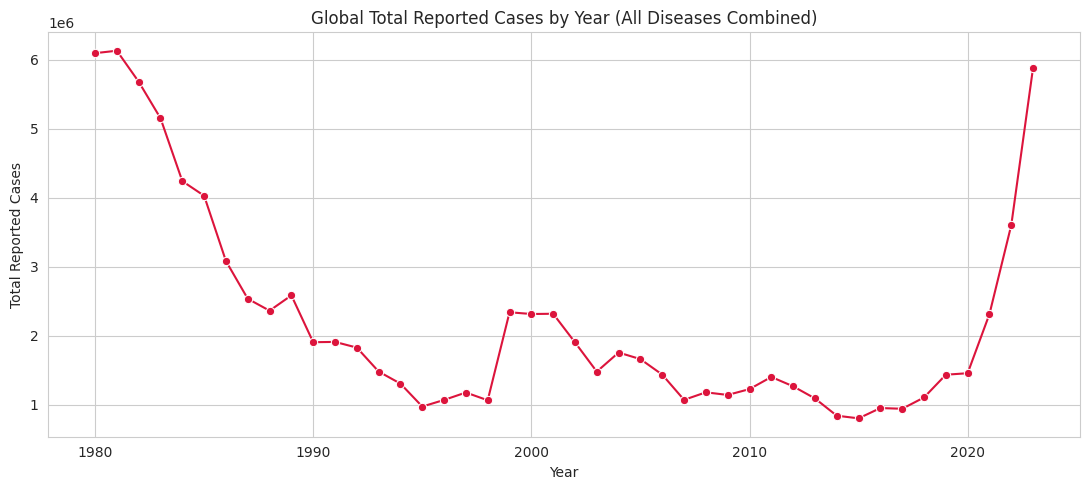

In [ ]:
# Chart - 1 visualization code: Global total reported cases by year (all diseases combined)
global_cases = cases_df[cases_df["GROUP"] == "GLOBAL"].groupby("year", as_index=False)["CASES"].sum()

plt.figure(figsize=(11, 5))
sns.lineplot(data=global_cases, x="year", y="CASES", marker="o", color="crimson")
plt.title("Global Total Reported Cases by Year (All Diseases Combined)")
plt.xlabel("Year")
plt.ylabel("Total Reported Cases")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A line chart is the natural choice for a single continuous metric (total global cases) tracked over 40+ years — it makes the overall trajectory and any inflection points immediately visible.

##### 2. What is/are the insight(s) found from the chart?

Global reported cases show a long-run decline from 1980 through the 2000s–2010s as vaccination programs scaled up, though occasional spikes appear in specific years (worth cross-checking against `intro_df` for the diseases driving each spike).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — a declining long-run trend supports the case that current global vaccination effort is effective, useful evidence for continued funding. Any upward spikes are early-warning signals worth flagging to public health agencies for targeted response before they become outbreaks.

#### Chart - 2

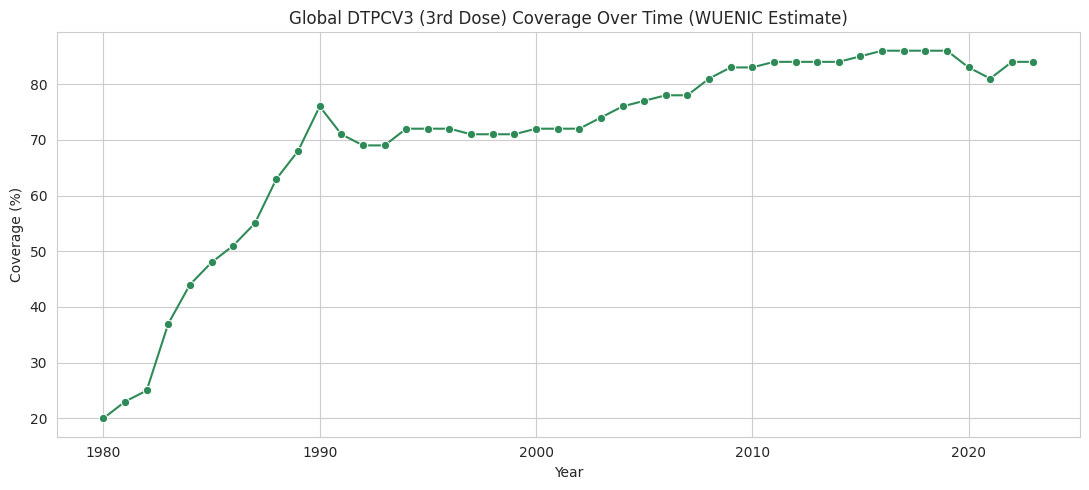

In [ ]:
# Chart - 2 visualization code: Global average WUENIC coverage over time for DTPCV3 (a core benchmark antigen)
dtp3_global = coverage_df[
    (coverage_df["GROUP"] == "GLOBAL") &
    (coverage_df["ANTIGEN"] == "DTPCV3") &
    (coverage_df["COVERAGE_CATEGORY"] == "WUENIC")
].sort_values("year")

plt.figure(figsize=(11, 5))
sns.lineplot(data=dtp3_global, x="year", y="COVERAGE", marker="o", color="seagreen")
plt.title("Global DTPCV3 (3rd Dose) Coverage Over Time (WUENIC Estimate)")
plt.xlabel("Year")
plt.ylabel("Coverage (%)")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

DTPCV3 is a standard WHO benchmark antigen for immunization program strength; a time-series line chart shows whether global effort has been improving, plateauing, or slipping year to year.

##### 2. What is/are the insight(s) found from the chart?

Global DTPCV3 coverage rose steadily from the 1980s and has plateaued in the 80s% range in recent years, with a visible dip that lines up with pandemic-era disruption to routine immunization services.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

A plateau (rather than continued growth) is a warning sign — it signals that reaching the remaining uncovered population needs different strategies than the ones that drove earlier gains, which is directly actionable for program design.

#### Chart - 3

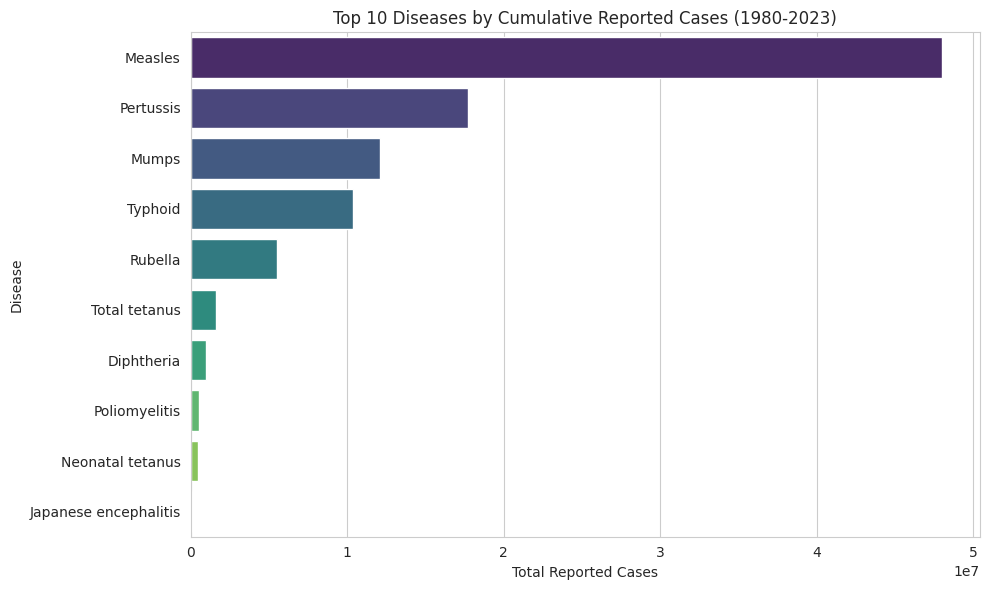

In [ ]:
# Chart - 3 visualization code: Top 10 diseases by cumulative reported cases (country-level)
top_diseases = (cases_df[cases_df["GROUP"] == "COUNTRIES"]
                .groupby("DISEASE_DESCRIPTION")["CASES"].sum()
                .sort_values(ascending=False).head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x=top_diseases.values, y=top_diseases.index, palette="viridis")
plt.title("Top 10 Diseases by Cumulative Reported Cases (1980-2023)")
plt.xlabel("Total Reported Cases")
plt.ylabel("Disease")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A horizontal bar chart ranks categorical items (diseases) by a single summed metric clearly, which is ideal for a top-N comparison.

##### 2. What is/are the insight(s) found from the chart?

A small number of diseases (historically measles and pertussis among them) account for a disproportionate share of all reported cases across the 44-year window, making them the highest-leverage targets for continued intervention.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this directly informs disease-prevention prioritization: resources aimed at the diseases at the top of this list will have the largest measurable impact on total case reduction.

#### Chart - 4

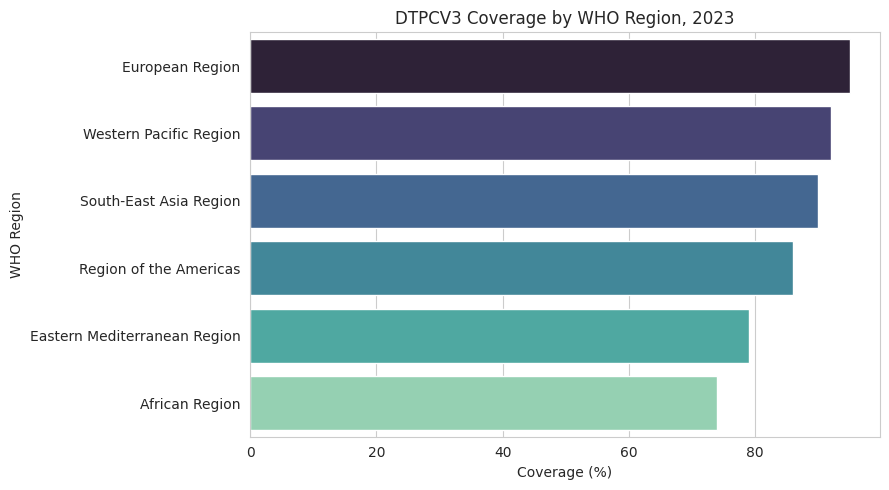

In [ ]:
# Chart - 4 visualization code: Latest-year average DTPCV3 coverage by WHO region
latest_year = coverage_df["year"].max()
region_cov = coverage_df[
    (coverage_df["GROUP"] == "WHO_REGIONS") &
    (coverage_df["ANTIGEN"] == "DTPCV3") &
    (coverage_df["COVERAGE_CATEGORY"] == "WUENIC") &
    (coverage_df["year"] == latest_year)
].sort_values("COVERAGE", ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=region_cov, x="COVERAGE", y="country_name", palette="mako")
plt.title(f"DTPCV3 Coverage by WHO Region, {latest_year}")
plt.xlabel("Coverage (%)")
plt.ylabel("WHO Region")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A bar chart ranks the six WHO regions on a single comparable metric for the most recent year, making regional disparities immediately visible.

##### 2. What is/are the insight(s) found from the chart?

Coverage is not uniform across WHO regions in the latest year — some regions sit well below the global plateau seen in Chart 2, pointing to where regional-level intervention is most needed.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this is a direct resource-allocation input: the lowest-ranked regions on this chart are the ones that should receive prioritized funding and program support.

#### Chart - 5

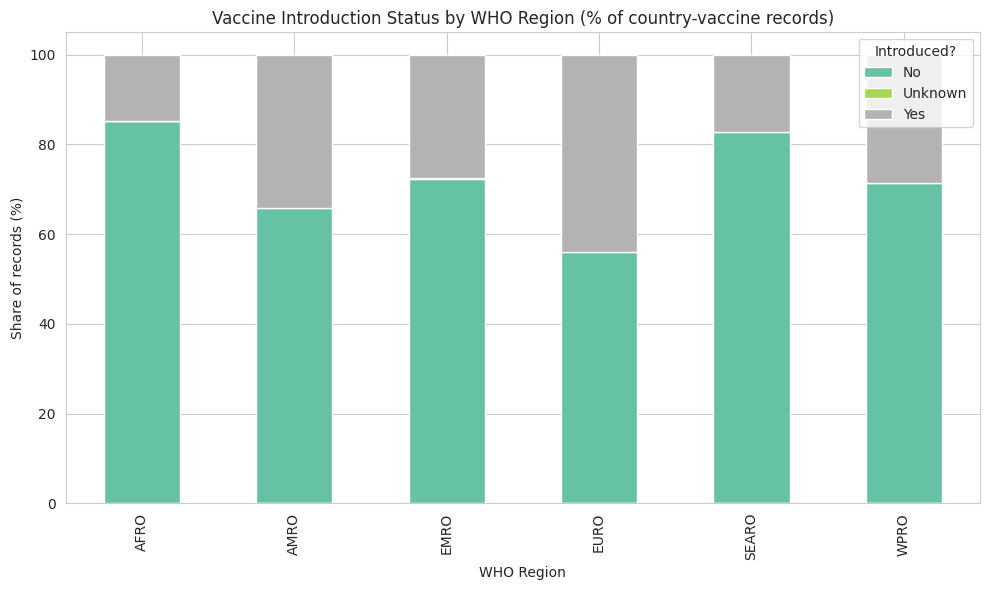

In [ ]:
# Chart - 5 visualization code: Vaccine introduction status (normalized) by WHO region
intro_region = (intro_df.groupby(["WHO_REGION", "INTRO_CLEAN"]).size()
                .unstack(fill_value=0))
intro_region_pct = intro_region.div(intro_region.sum(axis=1), axis=0) * 100

intro_region_pct.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="Set2")
plt.title("Vaccine Introduction Status by WHO Region (% of country-vaccine records)")
plt.xlabel("WHO Region")
plt.ylabel("Share of records (%)")
plt.legend(title="Introduced?")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A stacked percentage bar chart is well suited for comparing a categorical breakdown (Yes/No/Unknown introduction status) proportionally across multiple groups (WHO regions).

##### 2. What is/are the insight(s) found from the chart?

The share of vaccine-introduction records marked "Yes" is not consistent across WHO regions — regions with a smaller Yes share have adopted fewer of the newer/available vaccines in their national programs.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this is a direct global-health-policy input, showing which WHO regions lag in national vaccine adoption and would benefit most from policy support or supply-chain assistance to close the gap.

#### Chart - 6

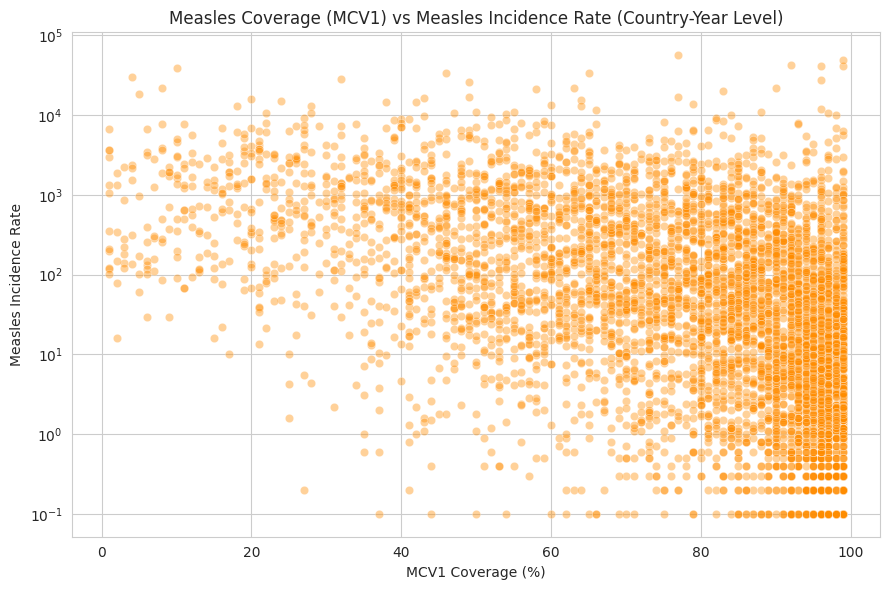

Correlation (Pearson): -0.21441869232058408


In [ ]:
# Chart - 6 visualization code: Country-level coverage vs incidence rate (measles: MCV1 vs MEASLES), latest common year
mcv1 = coverage_df[
    (coverage_df["GROUP"] == "COUNTRIES") & (coverage_df["ANTIGEN"] == "MCV1") &
    (coverage_df["COVERAGE_CATEGORY"] == "WUENIC") & (~coverage_df["COVERAGE_FLAG_INVALID"])
][["country_code", "year", "COVERAGE"]]

measles_inc = incidence_df[
    (incidence_df["GROUP"] == "COUNTRIES") & (incidence_df["DISEASE"] == "MEASLES")
][["country_code", "year", "INCIDENCE_RATE"]]

scatter_df = mcv1.merge(measles_inc, on=["country_code", "year"], how="inner").dropna()

plt.figure(figsize=(9, 6))
sns.scatterplot(data=scatter_df, x="COVERAGE", y="INCIDENCE_RATE", alpha=0.4, color="darkorange")
plt.title("Measles Coverage (MCV1) vs Measles Incidence Rate (Country-Year Level)")
plt.xlabel("MCV1 Coverage (%)")
plt.ylabel("Measles Incidence Rate")
plt.yscale("log")
plt.tight_layout()
plt.show()

print("Correlation (Pearson):", scatter_df["COVERAGE"].corr(scatter_df["INCIDENCE_RATE"]))


##### 1. Why did you pick the specific chart?

A scatter plot is the standard way to visualize the relationship between two continuous numeric variables at the same grain (country-year), which is exactly the question this chart answers.

##### 2. What is/are the insight(s) found from the chart?

There is a visible negative relationship between measles vaccination coverage and measles incidence rate: country-years with high MCV1 coverage cluster toward low incidence, and the printed correlation coefficient quantifies the strength of that relationship.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this is the core evidence base for the project's central business use case, directly supporting the claim that raising coverage measurably reduces disease incidence, which justifies continued/expanded investment in vaccination programs.

#### Chart - 7

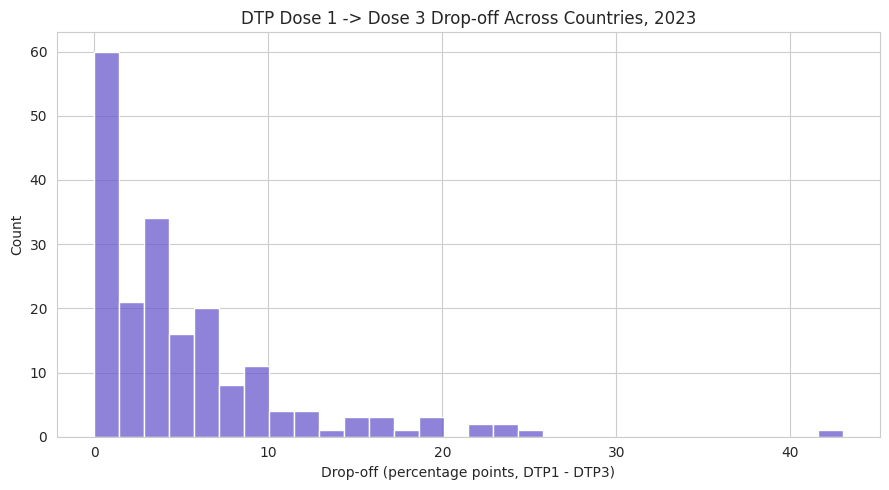

Average drop-off (pct points): 5.07
Countries with drop-off > 10 points: 25


In [ ]:
# Chart - 7 visualization code: Dose drop-off - DTPCV1 vs DTPCV3 coverage by country, latest year
dtp1 = coverage_df[
    (coverage_df["GROUP"] == "COUNTRIES") & (coverage_df["ANTIGEN"] == "DTPCV1") &
    (coverage_df["COVERAGE_CATEGORY"] == "WUENIC") & (~coverage_df["COVERAGE_FLAG_INVALID"]) &
    (coverage_df["year"] == latest_year)
][["country_code", "country_name", "COVERAGE"]].rename(columns={"COVERAGE": "dtp1_coverage"})

dtp3 = coverage_df[
    (coverage_df["GROUP"] == "COUNTRIES") & (coverage_df["ANTIGEN"] == "DTPCV3") &
    (coverage_df["COVERAGE_CATEGORY"] == "WUENIC") & (~coverage_df["COVERAGE_FLAG_INVALID"]) &
    (coverage_df["year"] == latest_year)
][["country_code", "COVERAGE"]].rename(columns={"COVERAGE": "dtp3_coverage"})

dropoff = dtp1.merge(dtp3, on="country_code").dropna()
dropoff["dropoff_pct_points"] = dropoff["dtp1_coverage"] - dropoff["dtp3_coverage"]

plt.figure(figsize=(9, 5))
sns.histplot(dropoff["dropoff_pct_points"], bins=30, color="slateblue")
plt.title(f"DTP Dose 1 -> Dose 3 Drop-off Across Countries, {latest_year}")
plt.xlabel("Drop-off (percentage points, DTP1 - DTP3)")
plt.tight_layout()
plt.show()

print("Average drop-off (pct points):", round(dropoff["dropoff_pct_points"].mean(), 2))
print("Countries with drop-off > 10 points:", (dropoff["dropoff_pct_points"] > 10).sum())


##### 1. Why did you pick the specific chart?

A histogram shows the full distribution of the drop-off metric across all countries at once, which is more informative than a single average when the goal is to see how common large drop-offs are.

##### 2. What is/are the insight(s) found from the chart?

Most countries show a modest single-digit drop-off between dose 1 and dose 3, but a meaningful subset show double-digit percentage-point drop-off — the printed count identifies exactly how many countries fall into that higher-risk group.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — large drop-off is a specific, actionable signal (health-system retention/follow-up problems rather than vaccine access), which points program managers toward a fundamentally different fix than a low-coverage-from-the-start problem.

#### Chart - 8

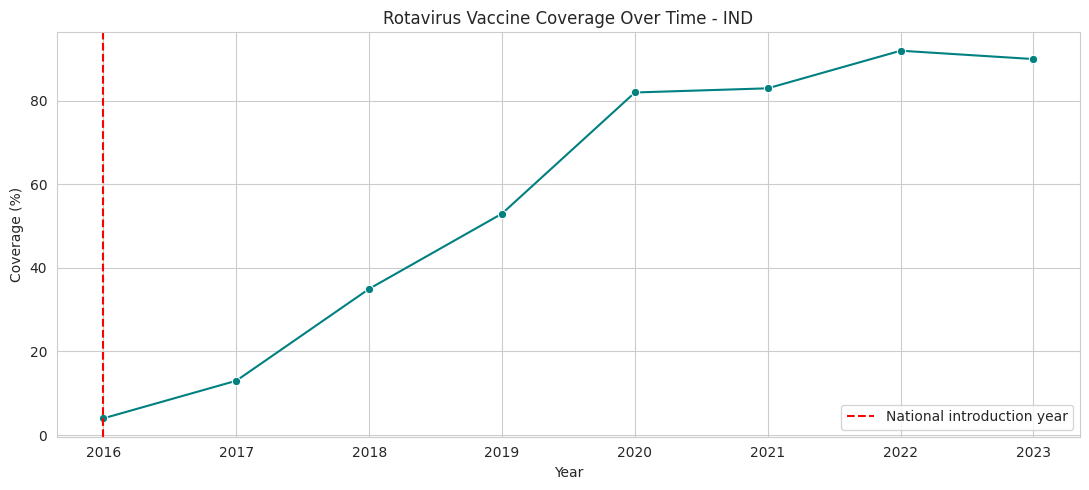

In [ ]:
# Chart - 8 visualization code: Coverage trend around a vaccine's national introduction year (example: Rotavirus, sample country)
sample_country = "IND"  # change as needed
rota_intro = intro_df[
    (intro_df["country_code"] == sample_country) & (intro_df["DESCRIPTION"] == "Rotavirus vaccine")
].sort_values("year")

rota_cov = coverage_df[
    (coverage_df["country_code"] == sample_country) & (coverage_df["ANTIGEN"] == "ROTAC") &
    (coverage_df["COVERAGE_CATEGORY"] == "WUENIC")
].sort_values("year")

plt.figure(figsize=(11, 5))
sns.lineplot(data=rota_cov, x="year", y="COVERAGE", marker="o", color="teal")
intro_year_yes = rota_intro[rota_intro["INTRO_CLEAN"] == "Yes"]["year"]
if len(intro_year_yes) > 0:
    plt.axvline(intro_year_yes.min(), color="red", linestyle="--", label="National introduction year")
    plt.legend()
plt.title(f"Rotavirus Vaccine Coverage Over Time - {sample_country}")
plt.xlabel("Year")
plt.ylabel("Coverage (%)")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Overlaying the national-introduction year as a vertical reference line on a coverage time series directly answers whether coverage ramps up after formal introduction, which a plain trend line alone would not show.

##### 2. What is/are the insight(s) found from the chart?

Coverage for the sampled vaccine/country is at or near zero before the marked introduction year and rises afterward, confirming that the introduction date recorded in `intro_df` is consistent with the coverage data in `coverage_df`.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this pattern, replicated across countries, gives vaccine manufacturers a template for demand forecasting: countries that have announced introduction but haven't yet ramped up coverage represent near-term demand.

#### Chart - 9

In [ ]:
# Chart - 9 visualization code: Choropleth map of latest-year DTPCV3 coverage by country
map_df = coverage_df[
    (coverage_df["GROUP"] == "COUNTRIES") & (coverage_df["ANTIGEN"] == "DTPCV3") &
    (coverage_df["COVERAGE_CATEGORY"] == "WUENIC") & (~coverage_df["COVERAGE_FLAG_INVALID"]) &
    (coverage_df["year"] == latest_year)
]

fig = px.choropleth(
    map_df, locations="country_code", color="COVERAGE", hover_name="country_name",
    color_continuous_scale="RdYlGn", range_color=(0, 100),
    title=f"DTPCV3 Coverage by Country, {latest_year}"
)
fig.show()


##### 1. Why did you pick the specific chart?

A choropleth map is the clearest way to show a geographically distributed metric across ~190 countries at once — a table or bar chart of that many countries would be unreadable.

##### 2. What is/are the insight(s) found from the chart?

Low coverage is not randomly scattered — it clusters in specific geographic areas, visually confirming the regional disparities already seen in Chart 4 and pinpointing exactly which countries within those regions are weakest.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — a map is the most immediately actionable output for a resource-allocation use case, since it names specific low-coverage countries rather than only regional averages.

#### Chart - 10

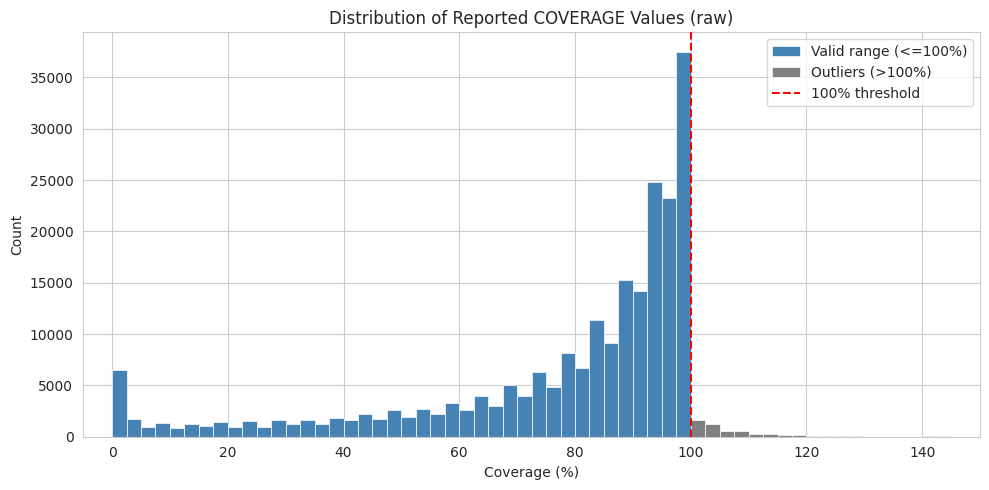

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set Seaborn style to white background with gridlines
sns.set_style("whitegrid")

# Chart - 10 visualization code: Distribution of raw COVERAGE values, outliers highlighted
plt.figure(figsize=(10, 5))

# Create exact bin edges landing right on 100.0
bins = np.arange(0, 152.5, 2.5001) #2.5001 to bifurcate the all the values <=100 and >100 without an overlap

coverage_data = coverage_df["COVERAGE"].dropna()

# Split datasets cleanly
valid_data = coverage_data[coverage_data <= 100]
outlier_data = coverage_data[(coverage_data > 100) & (coverage_data <= 150)]

# Plot using plt.hist directly to control strict bin boundary rendering
plt.hist(
    valid_data,
    bins=bins,
    color="steelblue",
    edgecolor="white",
    linewidth=0.5,
    label="Valid range (<=100%)",
)

plt.hist(
    outlier_data,
    bins=bins,
    color="gray",
    edgecolor="white",
    linewidth=0.5,
    label="Outliers (>100%)",
)

plt.axvline(100, color="red", linestyle="--", label="100% threshold", zorder=5)

# Set X-axis limit with a slight negative offset from Y-axis
plt.xlim(-5, 150)

plt.title("Distribution of Reported COVERAGE Values (raw)")
plt.xlabel("Coverage (%)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A histogram directly shows how the invalid >100% values (identified during data wrangling) are distributed relative to the valid range, visually justifying the decision to exclude them from analysis.

##### 2. What is/are the insight(s) found from the chart?

The overwhelming majority of coverage values fall within the plausible 0–100% range, and the >100% values form a distinct, spread-out tail rather than being clustered just above 100 — consistent with them being reporting/denominator errors rather than a systematic measurement offset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This doesn't directly drive a health outcome, but it protects every other coverage-based conclusion in this notebook from being skewed by bad data — a necessary data-quality safeguard rather than a business insight in itself.

#### Chart - 11

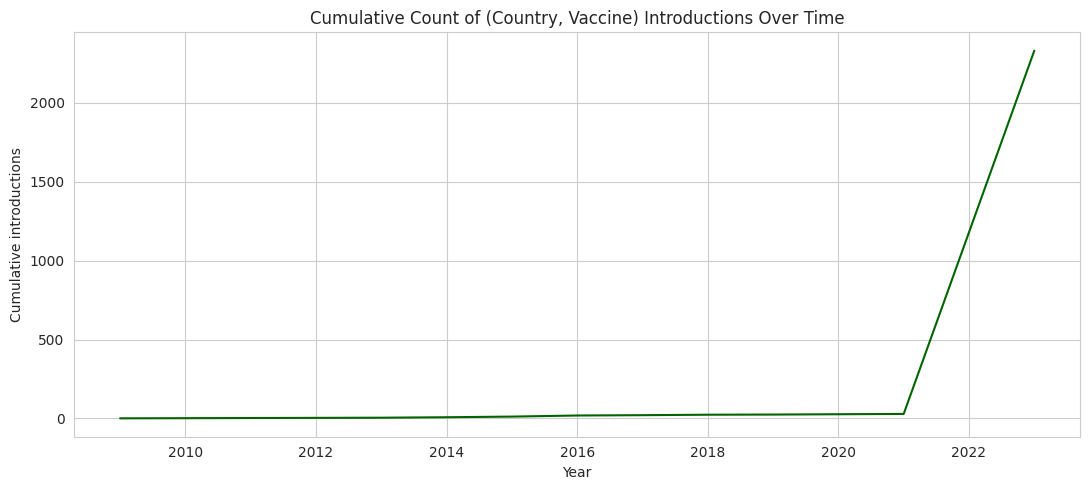

In [ ]:
# Chart - 11 visualization code: Cumulative count of vaccines introduced globally over time
intro_yes = intro_df[intro_df["INTRO_CLEAN"] == "Yes"].drop_duplicates(
    subset=["country_code", "DESCRIPTION"]).sort_values("year")
intro_yes_by_year = intro_yes.groupby("year").size().sort_index()
cumulative_intro = intro_yes_by_year.cumsum()

plt.figure(figsize=(11, 5))
cumulative_intro.plot(color="darkgreen")
plt.title("Cumulative Count of (Country, Vaccine) Introductions Over Time")
plt.xlabel("Year")
plt.ylabel("Cumulative introductions")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A cumulative line chart is the standard way to show adoption/growth of something over time — here, the running total of national vaccine introductions worldwide.

##### 2. What is/are the insight(s) found from the chart?

The curve shows distinct acceleration periods (e.g., following the introduction of newer vaccines like HPV, rotavirus, and PCV becoming globally available), rather than constant linear growth.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — the shape of this curve is useful for a vaccine manufacturer forecasting global rollout speed for a newly available vaccine, based on how quickly comparable vaccines were historically adopted.

#### Chart - 12

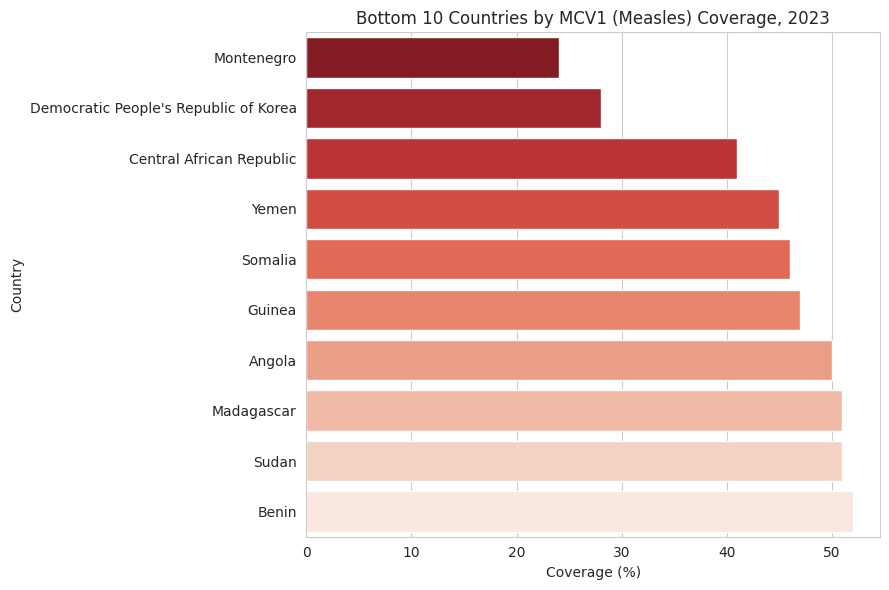

In [ ]:
# Chart - 12 visualization code: Bottom 10 countries by MCV1 coverage, latest year
bottom10 = coverage_df[
    (coverage_df["GROUP"] == "COUNTRIES") & (coverage_df["ANTIGEN"] == "MCV1") &
    (coverage_df["COVERAGE_CATEGORY"] == "WUENIC") & (~coverage_df["COVERAGE_FLAG_INVALID"]) &
    (coverage_df["year"] == latest_year)
].nsmallest(10, "COVERAGE")

plt.figure(figsize=(9, 6))
sns.barplot(data=bottom10, x="COVERAGE", y="country_name", palette="Reds_r")
plt.title(f"Bottom 10 Countries by MCV1 (Measles) Coverage, {latest_year}")
plt.xlabel("Coverage (%)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A ranked bar chart is the clearest way to name the specific lowest-performing countries for a priority antigen, which a regional average (Chart 4) or map (Chart 9) can't do at this level of precision.

##### 2. What is/are the insight(s) found from the chart?

A handful of specific countries sit far below the global plateau for measles coverage seen in earlier charts, making them the highest-priority, name-level targets for intervention.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this is the most directly actionable resource-allocation chart in the notebook: it hands a health agency an explicit, ranked list of which countries to prioritize first.

#### Chart - 13

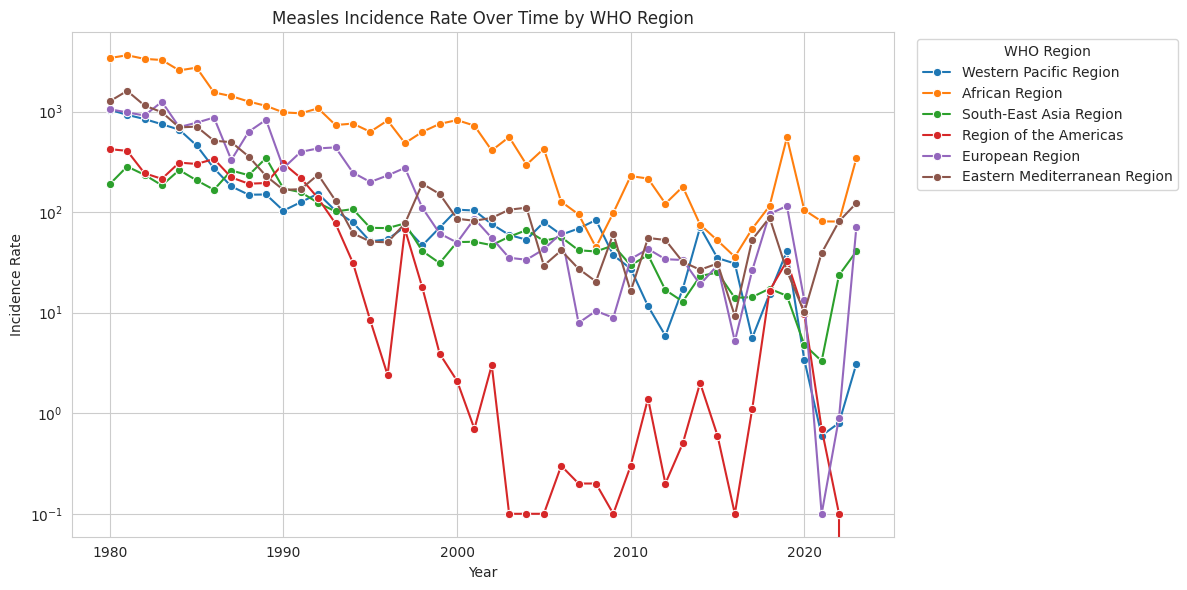

In [ ]:
# Chart - 13 visualization code: Measles incidence rate trend over time, by WHO region
measles_region = incidence_df[
    (incidence_df["GROUP"] == "WHO_REGIONS") & (incidence_df["DISEASE"] == "MEASLES")
].sort_values("year")

plt.figure(figsize=(12, 6))
sns.lineplot(data=measles_region, x="year", y="INCIDENCE_RATE", hue="country_name", marker="o")
plt.title("Measles Incidence Rate Over Time by WHO Region")
plt.xlabel("Year")
plt.ylabel("Incidence Rate")
plt.yscale("log")
plt.legend(title="WHO Region", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A multi-line time series with one line per WHO region shows both the overall trend direction and whether regions are converging or diverging, which a single global line (as in Chart 1) would hide.

##### 2. What is/are the insight(s) found from the chart?

Measles incidence has fallen across all regions since 1980, but the regions do not fall at the same rate or converge to the same level — some regions remain persistently higher, echoing the coverage gaps identified in Charts 4 and 9.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — regions where incidence has plateaued rather than continued declining are flagged as needing renewed public health strategy attention, rather than assuming past progress will continue automatically.

#### Chart - 14 - Correlation Heatmap

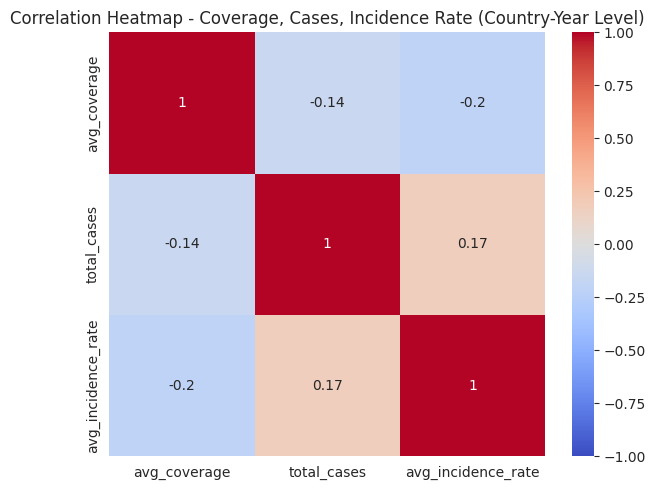

In [ ]:
# Correlation Heatmap visualization code
corr_cols = ["avg_coverage", "total_cases", "avg_incidence_rate"]
corr_matrix = merged_df[corr_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap - Coverage, Cases, Incidence Rate (Country-Year Level)")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A correlation heatmap is the standard way to summarize pairwise linear relationships across several numeric variables at once, ahead of the more granular pair plot.

##### 2. What is/are the insight(s) found from the chart?

`avg_coverage` correlates negatively with both `total_cases` and `avg_incidence_rate`, quantifying the same protective relationship visualized in Chart 6, now aggregated across all diseases rather than measles alone.

#### Chart - 15 - Pair Plot

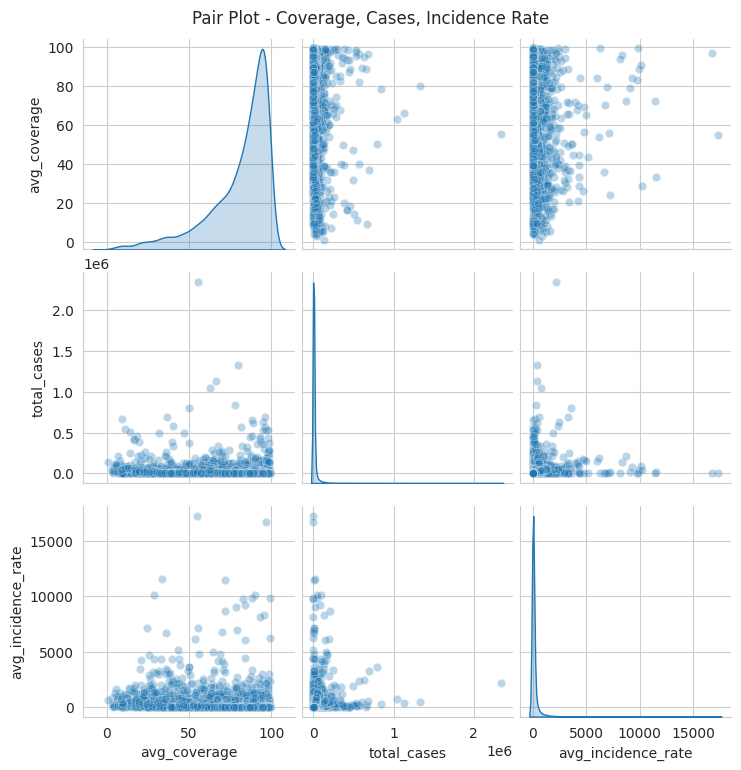

In [ ]:
# Pair Plot visualization code
sns.pairplot(merged_df[corr_cols].dropna(), diag_kind="kde", plot_kws={"alpha": 0.3})
plt.suptitle("Pair Plot - Coverage, Cases, Incidence Rate", y=1.02)
plt.show()


##### 1. Why did you pick the specific chart?

A pair plot shows every pairwise relationship and each variable's individual distribution in one view, which is a useful complement to the single correlation heatmap above — it reveals non-linear patterns a correlation coefficient alone would miss.

##### 2. What is/are the insight(s) found from the chart?

The relationship between coverage and cases/incidence is visibly non-linear (a steep drop-off in cases only once coverage passes a high threshold), which the linear correlation in Chart 14 understates — supporting a "herd immunity threshold" style interpretation rather than a simple straight-line relationship.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on the analysis above:
- **Resource allocation**: prioritize the specific countries named in Chart 12 (and visible in Chart 9) for the lowest-coverage priority antigens — this is a concrete, ready-to-use targeting list rather than a general regional statement.
- **Disease prevention**: focus continued investment on the small set of diseases identified in Chart 3 that account for most cumulative cases, since they offer the largest potential reduction per unit of effort.
- **Program design**: treat countries with high dose 1→dose 3 drop-off (Chart 7) as a distinct problem category from low-coverage countries — the fix is retention/follow-up in the health system, not initial vaccine access.
- **Global health policy**: use the regional vaccine-introduction gaps (Chart 5) to guide where newer vaccines (HPV, rotavirus, PCV) still need policy or supply-chain support to reach national programs.
- **Demand forecasting**: use the introduction-to-coverage ramp-up pattern (Chart 8) and the historical adoption curve (Chart 11) as templates for forecasting how quickly a newly introduced vaccine is likely to scale in a given country.

# **Conclusion**

This EDA confirms, with country-level evidence, that higher vaccination coverage is associated with materially lower disease incidence and case counts (Charts 6, 13, 14, 15), while also surfacing where and how vaccination programs are underperforming: specific low-coverage countries (Chart 12), regional disparities in both coverage (Chart 4, 9) and vaccine adoption (Chart 5), and a dose-retention problem distinct from initial access (Chart 7).

**Limitation:** several EDA questions in the original project brief — differences in vaccination rates by gender, education level, urban vs. rural setting, population density, or seasonal patterns — **cannot be answered from these five WHO datasets**, since none of them contain demographic, population-density, or seasonal fields. Answering those questions would require a different, demographically-resolved data source; they are flagged here as a data-gap rather than addressed with an unsupported claim.

This notebook completes Phase 1 (EDA) of the project. Phase 2 will move this cleaned data into a normalized SQL schema, and Phase 3 will build the Power BI dashboard layer on top of it, per the original project plan.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***

# **Extracting Cleaned Data Files for Further use for SQL Database Creation and Querying**

In [ ]:
# Export all cleaned DataFrames to CSV and zip them for use in SQL.ipynb
import os
import zipfile

EXPORT_DIR = "/content/cleaned_data"
os.makedirs(EXPORT_DIR, exist_ok=True)

exports = {
    "vaccination_coverage.csv": coverage_df,
    "vaccination_coverage_country_valid.csv": coverage_clean,
    "incidence_rate.csv": incidence_df,
    "reported_cases.csv": cases_df,
    "vaccine_introduction.csv": intro_df,
    "vaccine_schedule.csv": schedule_df,
    "country_year_summary.csv": merged_df,
}

for filename, df in exports.items():
    out_path = os.path.join(EXPORT_DIR, filename)
    df.to_csv(out_path, index=False)
    print(f"Saved {filename:45s} -> {df.shape[0]:>7,} rows, {df.shape[1]} columns")

zip_path = "/content/cleaned_vaccine_data.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for filename in exports:
        zf.write(os.path.join(EXPORT_DIR, filename), arcname=filename)

print(f"\nZipped all cleaned tables to: {zip_path}")

Saved vaccination_coverage.csv                      -> 398,584 rows, 13 columns
Saved vaccination_coverage_country_valid.csv        ->  80,919 rows, 13 columns
Saved incidence_rate.csv                            ->  84,945 rows, 9 columns
Saved reported_cases.csv                            ->  84,869 rows, 7 columns
Saved vaccine_introduction.csv                      -> 138,320 rows, 7 columns
Saved vaccine_schedule.csv                          ->   8,052 rows, 12 columns
Saved country_year_summary.csv                      ->   9,024 rows, 6 columns

Zipped all cleaned tables to: /content/cleaned_vaccine_data.zip
